In [ ]:
# =========================================
# 0. Imports
# =========================================
import os
import subprocess
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import pingouin as pg


# =========================================
# 1. Config
# =========================================
OUTPUT_DIR = os.path.expanduser("local_arm_restrain_icc")
TEMP_AUDIO_DIR = os.path.join(OUTPUT_DIR, "temp_audio")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TEMP_AUDIO_DIR, exist_ok=True)

VIDEO_FILES = [
    "/gpfs/data/shenlab/data/pediatric_psychiatry/COPE_Videos_PHI_confidential/6_Months/18/E1/18_6_Arm_Restraint.mov",
    "/gpfs/data/shenlab/data/pediatric_psychiatry/COPE_Videos_PHI_confidential/12_Months/N410/E1/N410_12_Arm_Restraint.mov",
]

TARGET_SR = 16000
MFCC_N = 13


# =========================================
# 2. restrain1 / restrain2 time and annotated score (for more videos, we can read from the given csv file)
# =========================================
video_meta = [
    {
        "video_path": "/gpfs/data/shenlab/data/pediatric_psychiatry/COPE_Videos_PHI_confidential/6_Months/18/E1/18_6_Arm_Restraint.mov",
        "subject_id": "18",
        "restrain1_start": 43,
        "restrain1_end": 76,
        "restrain1_score": 2.5,
        "restrain2_start": 120,
        "restrain2_end": 150,
        "restrain2_score": 2.0,
    },
    {
        "video_path": "/gpfs/data/shenlab/data/pediatric_psychiatry/COPE_Videos_PHI_confidential/12_Months/N410/E1/N410_12_Arm_Restraint.mov",
        "subject_id": "N410",
        "restrain1_start": 47,
        "restrain1_end": 60,
        "restrain1_score": 0.0,
        "restrain2_start": 98,
        "restrain2_end": 109,
        "restrain2_score": 1.0,
    },
]

video_meta_df = pd.DataFrame(video_meta)
print(video_meta_df)

In [ ]:
# =========================================
# Helper functions
# =========================================

def extract_audio_to_wav(video_path, wav_path, sr=16000):
    cmd = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", str(sr),
        wav_path
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"ffmpeg failed for {video_path}\n{result.stderr}")


def compute_mfcc_features(y_seg, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y=y_seg, sr=sr, n_mfcc=n_mfcc)
    mfcc_means = mfcc.mean(axis=1)

    out = {}
    for i in range(n_mfcc):
        out[f"mfcc_{i+1}_mean"] = float(mfcc_means[i])

    return out


def compute_icc_with_pingouin(df, score_col="annotated_score", mfcc_col="mfcc_score"):
    """
    use pingouin.intraclass_corr to get ICC
    each target = one restrain segment from one subject
    two rater = annotated / mfcc
    do z-score first to make them on the same scale, and also handle the case when all annotated scores are the same (std=0)
    """
    sub = df.dropna(subset=["subject_id", "segment", score_col, mfcc_col]).copy()

    if len(sub) < 2:
        print("Not enough rows for ICC.")
        return None, None

    sub["annotated_z"] = (sub[score_col] - sub[score_col].mean()) / sub[score_col].std(ddof=0)
    sub["mfcc_z"] = (sub[mfcc_col] - sub[mfcc_col].mean()) / sub[mfcc_col].std(ddof=0)

    sub["annotated_z"] = sub["annotated_z"].replace([np.inf, -np.inf], np.nan).fillna(0)
    sub["mfcc_z"] = sub["mfcc_z"].replace([np.inf, -np.inf], np.nan).fillna(0)

    sub["target"] = sub["subject_id"].astype(str) + "_" + sub["segment"].astype(str)

    long_df = pd.concat([
        pd.DataFrame({
            "target": sub["target"],
            "rater": "annotated",
            "rating": sub["annotated_z"]
        }),
        pd.DataFrame({
            "target": sub["target"],
            "rater": "mfcc",
            "rating": sub["mfcc_z"]
        })
    ], ignore_index=True)

    icc_df = pg.intraclass_corr(
        data=long_df,
        targets="target",
        raters="rater",
        ratings="rating"
    )

    return icc_df, long_df

In [21]:
rows = []

for _, meta in video_meta_df.iterrows():
    video_path = meta["video_path"]
    subject_id = meta["subject_id"]

    if not os.path.exists(video_path):
        print(f"[WARN] Video not found: {video_path}")
        continue

    wav_path = os.path.join(TEMP_AUDIO_DIR, f"{subject_id}_arm_restrain.wav")

    try:
        extract_audio_to_wav(video_path, wav_path, sr=TARGET_SR)
        y, sr = librosa.load(wav_path, sr=None)

        for seg_name in ["restrain1", "restrain2"]:
            start_sec = float(meta[f"{seg_name}_start"])
            end_sec = float(meta[f"{seg_name}_end"])
            annotated_score = float(meta[f"{seg_name}_score"])

            start_sample = int(start_sec * sr)
            end_sample = int(end_sec * sr)

            y_seg = y[start_sample:end_sample]

            if len(y_seg) == 0:
                print(f"[WARN] Empty segment for {subject_id} {seg_name}")
                continue

            mfcc_dict = compute_mfcc_features(y_seg, sr, n_mfcc=MFCC_N)

            row = {
                "subject_id": subject_id,
                "video_path": video_path,
                "segment": seg_name,
                "start_sec": start_sec,
                "end_sec": end_sec,
                "duration_sec": end_sec - start_sec,
                "annotated_score": annotated_score
            }
            row.update(mfcc_dict)
            rows.append(row)

        print(f"[OK] Processed {subject_id}")

    except Exception as e:
        print(f"[ERROR] {subject_id}: {e}")

results_df = pd.DataFrame(rows)

print("results_df shape:", results_df.shape)
display(results_df.head())

[OK] Processed 18
[OK] Processed N410
results_df shape: (4, 20)


,subject_id,video_path,segment,start_sec,end_sec,duration_sec,annotated_score,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean
0,18,/Users/iriswu/Desktop/1006 Capstone/presentati...,restrain1,43.0,76.0,33.0,2.5,-422.066742,122.866219,19.687792,0.543280,1.144932,4.155581,-3.770656,5.329661,2.139000,0.698406,-0.164276,4.939929,4.585241
1,18,/Users/iriswu/Desktop/1006 Capstone/presentati...,restrain2,120.0,150.0,30.0,2.0,-441.532440,134.094864,23.526661,4.723344,5.612513,2.607097,-0.148432,5.833179,2.432044,2.906202,1.592018,1.179387,0.678636
2,N410,/Users/iriswu/Desktop/1006 Capstone/presentati...,restrain1,47.0,60.0,13.0,0.0,-368.381866,48.387554,14.204537,2.764234,-13.465941,-5.439929,4.659802,2.509767,-9.640965,2.453918,-0.260553,1.407189,5.140330
3,N410,/Users/iriswu/Desktop/1006 Capstone/presentati...,restrain2,98.0,109.0,11.0,1.0,-413.255554,65.937576,12.856343,9.876455,1.831923,-6.874864,-3.302723,-0.472962,-0.962427,3.285757,-3.284986,1.139184,1.604723


In [23]:
display(
    results_df[[
        "subject_id", "segment",
        "start_sec", "end_sec",
        "annotated_score"
    ]]
)

,subject_id,segment,start_sec,end_sec,annotated_score
0,18,restrain1,43.0,76.0,2.5
1,18,restrain2,120.0,150.0,2.0
2,N410,restrain1,47.0,60.0,0.0
3,N410,restrain2,98.0,109.0,1.0


In [24]:
def compute_icc_for_feature(df, feature_col, score_col="annotated_score"):
    sub = df.dropna(subset=["subject_id", "segment", score_col, feature_col]).copy()

    if len(sub) < 2:
        return None, None

    sub["annotated_z"] = (sub[score_col] - sub[score_col].mean()) / sub[score_col].std(ddof=0)
    sub["feature_z"] = (sub[feature_col] - sub[feature_col].mean()) / sub[feature_col].std(ddof=0)

    sub["annotated_z"] = sub["annotated_z"].replace([np.inf, -np.inf], np.nan).fillna(0)
    sub["feature_z"] = sub["feature_z"].replace([np.inf, -np.inf], np.nan).fillna(0)

    sub["target"] = sub["subject_id"].astype(str) + "_" + sub["segment"].astype(str)

    long_df = pd.concat([
        pd.DataFrame({
            "target": sub["target"],
            "rater": "annotated",
            "rating": sub["annotated_z"]
        }),
        pd.DataFrame({
            "target": sub["target"],
            "rater": feature_col,
            "rating": sub["feature_z"]
        })
    ], ignore_index=True)

    icc_df = pg.intraclass_corr(
        data=long_df,
        targets="target",
        raters="rater",
        ratings="rating"
    )

    return icc_df, long_df

In [29]:
icc_summary_rows = []

feature_cols = [f"mfcc_{i}_mean" for i in range(1, 14)]

for feat in feature_cols:
    try:
        icc_df, _ = compute_icc_for_feature(results_df, feature_col=feat)

        if icc_df is None or icc_df.empty:
            print(f"[WARN] No ICC result for {feat}")
            continue

        row_target = icc_df[icc_df["Type"] == "ICC(A,1)"]

        if row_target.empty:
            print(f"[WARN] No ICC(A,1) row for {feat}")
            continue

        row_target = row_target.iloc[0]

        icc_summary_rows.append({
            "feature": feat,
            "ICC_type": row_target["Type"],
            "ICC": row_target["ICC"],
            "pval": row_target["pval"],
            "CI95": str(row_target["CI95"])
        })

    except Exception as e:
        print(f"[ERROR] {feat}: {e}")

icc_summary_df = pd.DataFrame(icc_summary_rows)

if not icc_summary_df.empty:
    icc_summary_df = icc_summary_df.sort_values("ICC", ascending=False)

display(icc_summary_df)

,feature,ICC_type,ICC,pval,CI95
8,mfcc_9_mean,"ICC(A,1)",0.951229,0.009621,[0.39 1. ]
1,mfcc_2_mean,"ICC(A,1)",0.950565,0.009814,[0.38 1. ]
5,mfcc_6_mean,"ICC(A,1)",0.909244,0.023730,[0.02 0.99]
4,mfcc_5_mean,"ICC(A,1)",0.850423,0.048254,[-0.34 0.99]
2,mfcc_3_mean,"ICC(A,1)",0.807874,0.068283,[-0.54 0.99]
7,mfcc_8_mean,"ICC(A,1)",0.719558,0.113664,[-0.84 0.98]
11,mfcc_12_mean,"ICC(A,1)",0.701612,0.123312,[-0.89 0.98]
10,mfcc_11_mean,"ICC(A,1)",0.424765,0.277994,[-1.36 0.95]
12,mfcc_13_mean,"ICC(A,1)",-0.421735,0.679641,[-1.8 0.83]
3,mfcc_4_mean,"ICC(A,1)",-0.440187,0.686508,[-1.8 0.83]


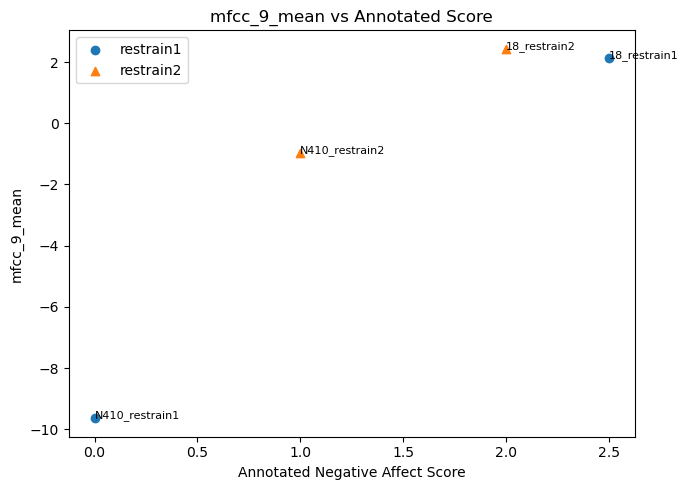

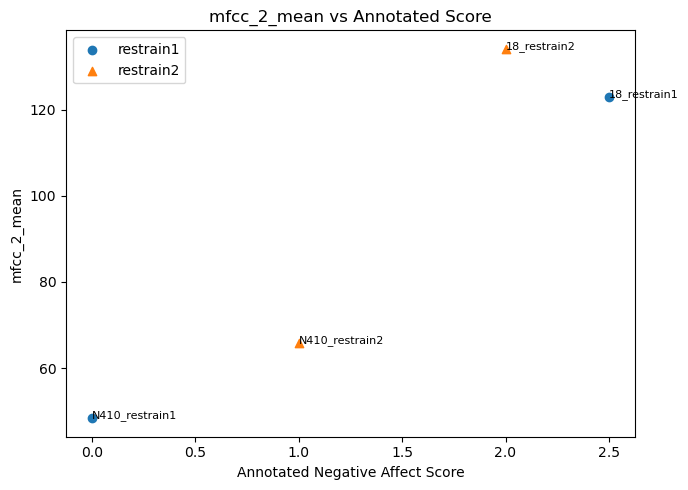

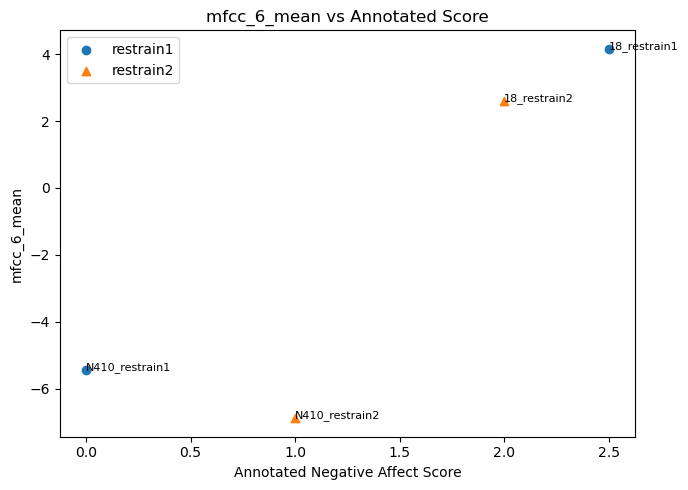

In [30]:
top_features = ["mfcc_9_mean", "mfcc_2_mean", "mfcc_6_mean"]

for feature_col in top_features:
    plt.figure(figsize=(7, 5))

    for seg_name, marker in [("restrain1", "o"), ("restrain2", "^")]:
        sub = results_df[results_df["segment"] == seg_name].dropna(subset=["annotated_score", feature_col]).copy()
        plt.scatter(sub["annotated_score"], sub[feature_col], marker=marker, label=seg_name)

        for _, r in sub.iterrows():
            plt.text(r["annotated_score"], r[feature_col], f'{r["subject_id"]}_{seg_name}', fontsize=8)

    plt.xlabel("Annotated Negative Affect Score")
    plt.ylabel(feature_col)
    plt.title(f"{feature_col} vs Annotated Score")
    plt.legend()
    plt.tight_layout()
    plt.show()